# 📘 Singular Value Decomposition (SVD) – Machine Learning Notes

## 🔍 What is SVD?

**Singular Value Decomposition (SVD)** is a fundamental technique in **Linear Algebra** used widely in **Unsupervised Machine Learning**, especially for:
- **Dimensionality Reduction**
- **Data Compression**
- **Noise Reduction**
- **Feature Selection**

> 💡 You’ve already used SVD indirectly while performing **PCA** (Principal Component Analysis). Now let’s understand how exactly it works under the hood.

---

## 🎯 Why SVD is Important in ML

SVD helps in breaking down a large matrix (your data) into smaller, manageable parts while retaining the essence of the original dataset. This allows:
- Reduced **memory consumption**
- Improved **computational efficiency**
- Extracting **dominant patterns** from high-dimensional data

---

## ⚙️ Definition of SVD

> “SVD is a **Linear Algebraic Method** that decomposes a matrix into three separate matrices.”

### Formula:
For any real matrix A = U Σ Vᵀ


Where:
- \( A \) = Original data matrix  
- \( U \) = Left **orthogonal** matrix (columns are unit orthogonal vectors)  
- \( Σ \) = Diagonal matrix with **singular values**  
- \( Vᵀ \) = Transpose of right **orthogonal** matrix

---

## 🧠 Analogy to Understand Decomposition

> Just like in biology, where a large molecule breaks down into smaller molecules (called **decomposition**), similarly, in SVD, a large data matrix is broken into smaller matrices.

Another analogy:  
> Think of **organic waste (compost)**: When buried, it breaks down into ash or soil — a form of **natural decomposition**.  
> SVD does the same: A big matrix breaks into small components while keeping the essence intact.

---



## 🔬 Matrix View of Data

Suppose you have features like:

Feature 1: 2, 4\
Feature 2: 4, 5, 6\
Feature 3: 10, 12, 15

All of this can be represented as a **matrix**. Each **row** = a data sample, and each **column** = a feature.

So, your **data = matrix**. SVD works by breaking this large matrix into **three** matrices — two of which are **orthogonal** (90° apart).

---

## 🎯 Goals of SVD

- **From High-Dimensional to Low-Dimensional**  
  Just like PCA, SVD reduces the number of dimensions to make computation easier and faster.

- **Data Compression**  
  Like PCA, SVD transforms a dataset with 26–27 features into just 1 or 2 — without losing much information.

- **Noise Reduction**  
  SVD helps remove outliers and irrelevant variations in data.

- **Feature Filtering**  
  It helps identify which features are most impactful.

---

## 📐 Orthogonal Matrix Analogy

When two vectors make a **90° angle**, they’re **orthogonal**.  
> Example: PC1 and PC2 in PCA — two directions that capture the most variance from different perspectives.

In SVD, the two matrices \( U \) and \( V \) are orthogonal — meaning they capture the **independent variation** in the dataset.

---



## 🔢 What is Matrix Factorization?

SVD is a form of **matrix factorization**:
- A large matrix is **factorized** into **two or three** smaller ones.
- These smaller matrices can then be used to:
  - Reconstruct the original data
  - Perform compression
  - Extract patterns (features)

> If two small matrices (e.g., 2x3 and 3x2) multiply, they produce a larger matrix — **just like small components forming a whole**.

---

## 🧭 Relation to PCA

SVD provides the **underlying mechanism** for PCA.

> In PCA:
- Eigenvectors = Principal Components (PCs)
- Eigenvalues = Explain how much variance each PC carries

SVD finds these components by:
- Decomposing the original matrix
- Producing the same directions (PCs) as PCA, but through **matrix decomposition**

---

## 🎓 Professor’s Sketch Analogy

> Imagine you rotate the entire dataset and place it onto a single line — this is the core idea of PCA.  
> SVD is the method that allows this rotation and projection mathematically.

So:
- **SVD helps you “see” the data** from the most meaningful directions (principal components).
- **These directions** (PC1, PC2) are just **eigenvectors** or **orthogonal unit vectors**.

---

## 📊 Latent Variables

These are **hidden patterns** or factors in your data.

- When SVD decomposes the matrix, it reveals these **latent variables** — the underlying structure.
- These form the **basis** for better predictions and interpretations.

---

## 💡 Key Takeaways

| Feature       | SVD                             | PCA                                |
|---------------|----------------------------------|-------------------------------------|
| Category      | Linear Algebra                  | ML Technique                        |
| Goal          | Decompose matrix                | Reduce dimensions                   |
| Output        | U, Σ, Vᵀ                        | Principal components                |
| Uses          | Image compression, NLP (LSA)    | Visualization, noise reduction      |
| Based On      | Matrix Decomposition            | Covariance Matrix                   |
| Math Required | No scaling/centering required   | Requires scaling + centering        |
| Relationship  | SVD powers PCA                  | PCA = SVD on Covariance Matrix      |

---





## 🔚 Final Thought

> **Why all this?**  
Because we want to reduce **high-dimensional data** into 2D or 3D for **visualization** or **model simplification**.

SVD is like a lens — it lets you **look at your dataset from the best angle** — the one that explains it most clearly.

---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

# Load dataset
df = sns.load_dataset('titanic')


In [3]:
df.columns 

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [4]:
features =['pclass','sex','age','fare','survived']

# Pipeline for numerical features
numerical_features = ['age', 'fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features
categorical_features = ['pclass', 'sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot_encoder', OneHotEncoder())
])
# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])
# Apply preprocessing
X = preprocessor.fit_transform(df[features])


In [5]:
df[features].head()

,pclass,sex,age,fare,survived
0,3,male,22.0,7.2500,0
1,1,female,38.0,71.2833,1
2,3,female,26.0,7.9250,1
3,1,female,35.0,53.1000,1
4,3,male,35.0,8.0500,0


In [6]:
X

array([[-0.5924806 , -0.50244517,  0.        , ...,  1.        ,
         0.        ,  1.        ],
       [ 0.63878901,  0.78684529,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [-0.2846632 , -0.48885426,  0.        , ...,  1.        ,
         1.        ,  0.        ],
       ...,
       [ 0.        , -0.17626324,  0.        , ...,  1.        ,
         1.        ,  0.        ],
       [-0.2846632 , -0.04438104,  1.        , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.17706291, -0.49237783,  0.        , ...,  1.        ,
         0.        ,  1.        ]], shape=(891, 7))

In [7]:
# perform SVD
svd = TruncatedSVD(n_components=2, random_state=42)
Y = svd.fit_transform(X)

# print the singular value and explained variance ratio
print(f'Singular values: {svd.singular_values_}')
print(f'Explained variance ratio: {svd.explained_variance_ratio_}')


Singular values: [34.01442224 29.8724527 ]
Explained variance ratio: [0.37226671 0.17290661]


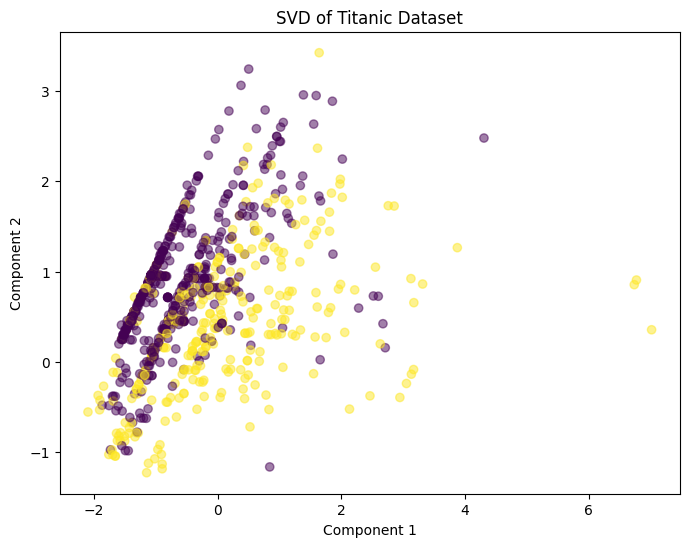

In [8]:
import matplotlib.pyplot as plt
# visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(Y[:, 0], Y[:, 1], c=df['survived'], cmap='viridis', alpha=0.5)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('SVD of Titanic Dataset')
plt.show()

# **SVD on Diamonds**

In [9]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt


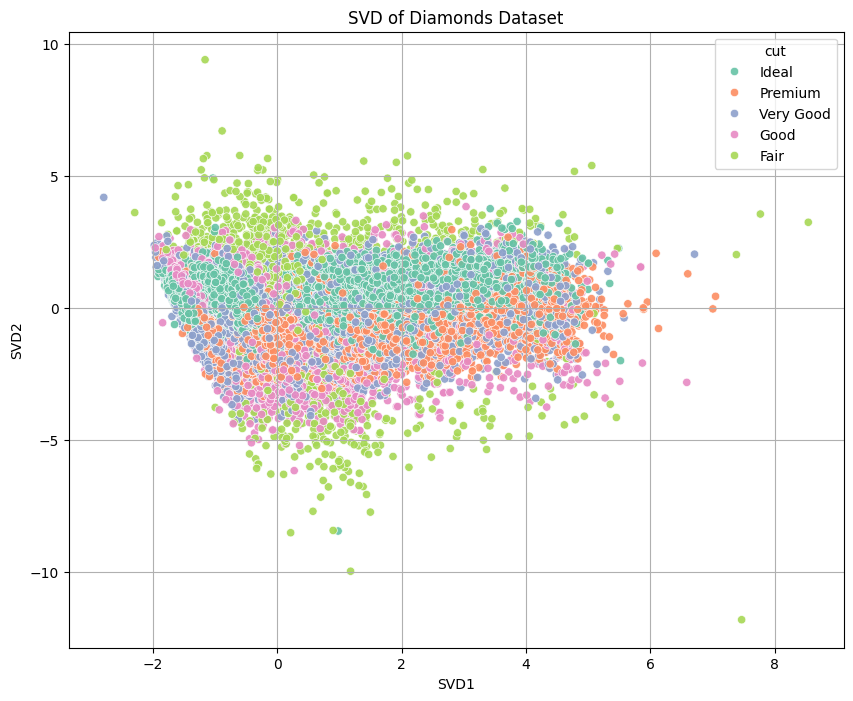

In [10]:
df = sns.load_dataset('diamonds')

# Select numerical features for SVD
features = ['carat', 'depth', 'table', 'price']
# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])
# Create transformer that will handle numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, features)
    ])
# Create a pipeline that includes the preprocessor and model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svd', TruncatedSVD(n_components=2, random_state=42))
]) 
# Apply the pipeline to the dataset
svd_result = pipeline.fit_transform(df[features])
# Create a DataFrame for the SVD results
svd_df = pd.DataFrame(svd_result, columns=['SVD1', 'SVD2'])
# Add the 'cut' feature to the SVD DataFrame
svd_df['cut'] = df['cut']

# Visualize the SVD results
plt.figure(figsize=(10, 8))
sns.scatterplot(data=svd_df, x='SVD1', y='SVD2', hue='cut', palette='Set2', alpha=0.9)
plt.xlabel('SVD1')
plt.ylabel('SVD2')
plt.title('SVD of Diamonds Dataset')
plt.grid(True)
plt.show()

In [11]:
print("Explained Variance by each component:")
print(svd.explained_variance_ratio_.round(2))
print("Total Variance Explained:", svd.explained_variance_ratio_.sum().round(2))


Explained Variance by each component:
[0.37 0.17]
Total Variance Explained: 0.55


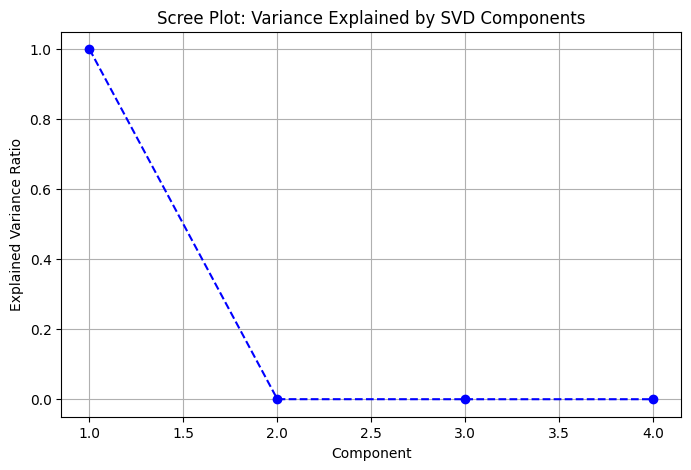

In [12]:
svd_full = TruncatedSVD(n_components=4)
svd_full.fit_transform(df[features])

plt.figure(figsize=(8,5))
plt.plot(range(1, 5), svd_full.explained_variance_ratio_, marker='o', linestyle='--', color='b')
plt.title("Scree Plot: Variance Explained by SVD Components")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()


### 📉 **What is a Scree Plot?**
A Scree Plot is a line plot that shows:

How much variance is explained by each principal component (or SVD component) in dimensionality reduction techniques like PCA or SVD.

### 🧠 **Purpose of a Scree Plot:**
It helps answer this question:

"How many components should I keep to capture most of the information (variance)?"

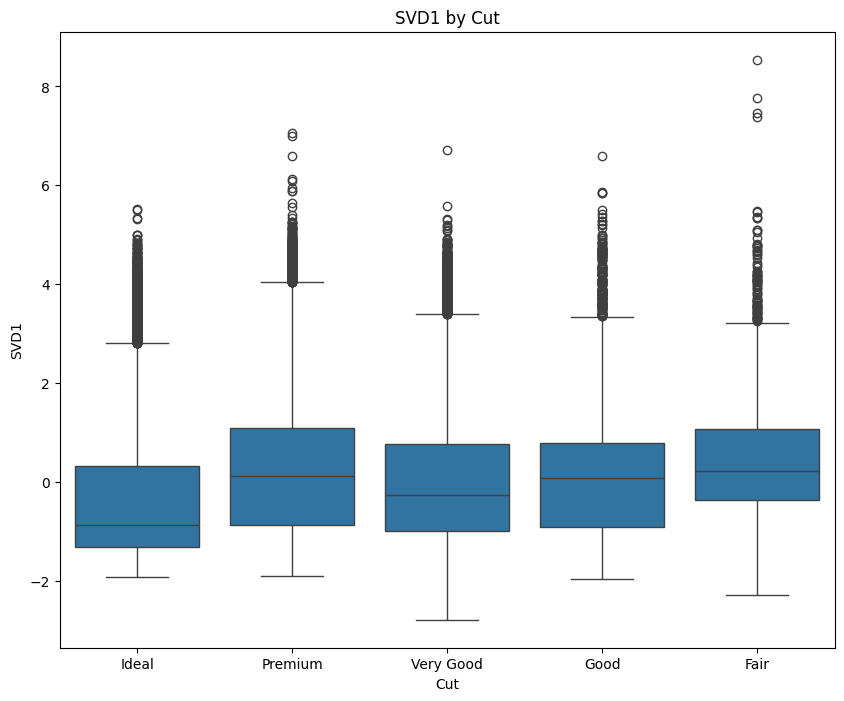

In [13]:
# Visualize the SVD results usin boxplot and only svd1
plt.figure(figsize=(10, 8))
sns.boxplot(x='cut', y='SVD1', data=svd_df)
plt.xlabel('Cut')
plt.ylabel('SVD1')
plt.title('SVD1 by Cut')

plt.show()

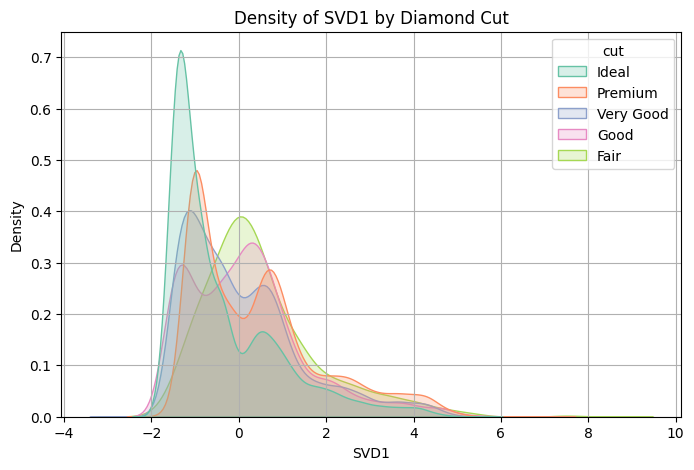

In [14]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=svd_df, x='SVD1', hue='cut', fill=True, common_norm=False, palette='Set2')
plt.title('Density of SVD1 by Diamond Cut')
plt.grid(True)
plt.show()


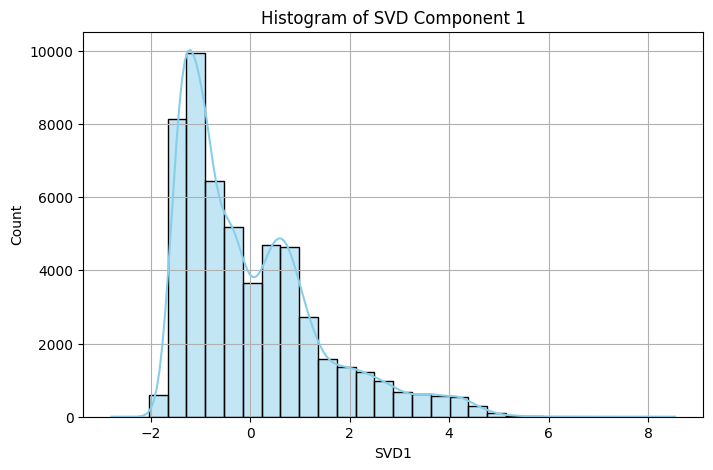

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(svd_df['SVD1'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of SVD Component 1')
plt.xlabel('SVD1')
plt.grid(True)
plt.show()
